### **Problem Statement**

### Developed an end-to-end machine learning system to assess insurance risk, predict healthcare claim costs, and recommend personalized insurance premiums. Performed exploratory data analysis, feature engineering, customer segmentation using K-Means clustering, and claim cost prediction using ensemble learning models. Built a premium optimization engine to balance customer affordability and company profitability, incorporated SHAP-based explainability for transparent decision-making, and designed interactive Power BI dashboards for risk and profit analysis.

### Importing Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab  import files
uploaded = files.upload()

Saving 1651277648862_healthinsurance.csv to 1651277648862_healthinsurance.csv


In [ ]:

df = pd.read_csv('1651277648862_healthinsurance.csv')


In [ ]:
df.tail()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
14995,39.0,male,49,28.3,NoDisease,1,1,Florence,54,1,0,FilmMaker,21082.2
14996,39.0,male,74,29.6,NoDisease,4,0,Miami,64,1,0,Student,7512.3
14997,20.0,male,62,33.3,NoDisease,0,0,Tampa,52,1,0,FashionDesigner,1391.5
14998,52.0,male,88,36.7,NoDisease,0,0,PanamaCity,70,1,0,Farmer,9144.6
14999,52.0,male,57,26.4,NoDisease,3,0,Kingsport,72,1,0,Manager,25992.8


In [ ]:
df.tail()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
14995,39.0,male,49,28.3,NoDisease,1,1,Florence,54,1,0,FilmMaker,21082.2
14996,39.0,male,74,29.6,NoDisease,4,0,Miami,64,1,0,Student,7512.3
14997,20.0,male,62,33.3,NoDisease,0,0,Tampa,52,1,0,FashionDesigner,1391.5
14998,52.0,male,88,36.7,NoDisease,0,0,PanamaCity,70,1,0,Farmer,9144.6
14999,52.0,male,57,26.4,NoDisease,3,0,Kingsport,72,1,0,Manager,25992.8


In [ ]:
df.sample(5)

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
9422,NaN,female,88,29.6,NoDisease,1,0,SanJose,78,0,0,Singer,3947.4
8867,18.0,male,64,25.5,NoDisease,0,0,Bakersfield,65,0,0,HomeMakers,1708.0
2632,31.0,male,80,31.1,NoDisease,3,0,Stamford,88,1,0,Manager,5425.0
11777,55.0,male,54,33.0,NoDisease,0,0,Montrose,60,1,0,Dancer,20781.5
1149,37.0,male,62,29.6,NoDisease,0,0,Fresno,88,0,1,Actor,5028.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  14604 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  14044 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  object 
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 1.5+ MB


In [ ]:
df.isnull().sum()

,0
age,396
sex,0
weight,0
bmi,956
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


In [ ]:
df.duplicated().sum()

np.int64(1096)

In [ ]:
df[df.duplicated()]

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
605,46.0,female,68,NaN,NoDisease,2,0,LosAngeles,60,1,0,Dancer,8825.1
608,27.0,female,82,NaN,NoDisease,3,0,Oceanside,82,1,1,Architect,18804.8
898,48.0,female,67,33.1,Alzheimer,0,1,Cincinnati,70,1,0,ITProfessional,40974.2
919,26.0,male,56,23.7,NoDisease,2,0,Kingman,72,1,0,HomeMakers,3484.3
970,48.0,female,70,28.9,NoDisease,1,0,KanasCity,72,0,0,Architect,9249.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14966,46.0,male,46,22.3,NoDisease,0,0,Louisville,72,1,0,Academician,7147.1
14971,18.0,female,53,27.3,NoDisease,3,1,Boston,85,1,0,Student,18223.5
14987,47.0,male,94,47.5,NoDisease,1,0,Raleigh,61,1,0,Academician,8083.9
14989,44.0,male,90,38.1,NoDisease,1,0,Georgia,76,1,0,Engineer,7152.7


In [ ]:
duplicates = df[df.duplicated(
    subset=df.columns.drop(['city']),
    keep=False
)]

In [ ]:
duplicates.shape

(14250, 13)

In [ ]:
df.drop('city', axis=1, inplace=True)

In [ ]:
df2 = df.drop_duplicates(keep='first')

In [ ]:
df2.shape

(2058, 12)

In [ ]:
df2.isnull().sum()

,0
age,40
sex,0
weight,0
bmi,143
hereditary_diseases,0
no_of_dependents,0
smoker,0
bloodpressure,0
diabetes,0
regular_ex,0


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2058 entries, 0 to 14988
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  2018 non-null   float64
 1   sex                  2058 non-null   object 
 2   weight               2058 non-null   int64  
 3   bmi                  1915 non-null   float64
 4   hereditary_diseases  2058 non-null   object 
 5   no_of_dependents     2058 non-null   int64  
 6   smoker               2058 non-null   int64  
 7   bloodpressure        2058 non-null   int64  
 8   diabetes             2058 non-null   int64  
 9   regular_ex           2058 non-null   int64  
 10  job_title            2058 non-null   object 
 11  claim                2058 non-null   float64
dtypes: float64(3), int64(6), object(3)
memory usage: 209.0+ KB


In [ ]:
df2.describe()

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim
count,2018.000000,2058.000000,1915.000000,2058.000000,2058.000000,2058.000000,2058.000000,2058.000000,2058.000000
mean,38.329039,64.852770,29.702193,1.067541,0.359086,69.999028,0.573858,0.431487,15913.601555
std,13.336340,13.013668,5.802190,1.139218,0.479849,19.661155,0.494635,0.495404,12120.298219
min,18.000000,34.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.900000
25%,27.000000,54.000000,25.600000,0.000000,0.000000,64.000000,0.000000,0.000000,6600.250000
50%,38.000000,64.000000,28.900000,1.000000,0.000000,72.000000,1.000000,0.000000,12318.500000
75%,49.000000,75.000000,33.600000,2.000000,1.000000,80.000000,1.000000,1.000000,22217.225000
max,64.000000,95.000000,53.100000,5.000000,1.000000,122.000000,1.000000,1.000000,63770.400000


In [ ]:
df2['age'] = df2['age'].fillna(df2['age'].median())



In [ ]:
df2['bmi'] = df2['bmi'].fillna(df2['bmi'].median())

In [ ]:
df2.isnull().sum()

,0
age,0
sex,0
weight,0
bmi,0
hereditary_diseases,0
no_of_dependents,0
smoker,0
bloodpressure,0
diabetes,0
regular_ex,0


In [ ]:
df2.to_csv('Cleaned_Insurance_data.csv', index=False)

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2058 entries, 0 to 14988
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  2058 non-null   float64
 1   sex                  2058 non-null   object 
 2   weight               2058 non-null   int64  
 3   bmi                  2058 non-null   float64
 4   hereditary_diseases  2058 non-null   object 
 5   no_of_dependents     2058 non-null   int64  
 6   smoker               2058 non-null   int64  
 7   bloodpressure        2058 non-null   int64  
 8   diabetes             2058 non-null   int64  
 9   regular_ex           2058 non-null   int64  
 10  job_title            2058 non-null   object 
 11  claim                2058 non-null   float64
dtypes: float64(3), int64(6), object(3)
memory usage: 209.0+ KB


In [ ]:
df2.describe()

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim
count,2058.000000,2058.000000,2058.000000,2058.000000,2058.000000,2058.000000,2058.000000,2058.000000,2058.000000
mean,38.322643,64.852770,29.646453,1.067541,0.359086,69.999028,0.573858,0.431487,15913.601555
std,13.206114,13.013668,5.600595,1.139218,0.479849,19.661155,0.494635,0.495404,12120.298219
min,18.000000,34.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.900000
25%,27.000000,54.000000,25.800000,0.000000,0.000000,64.000000,0.000000,0.000000,6600.250000
50%,38.000000,64.000000,28.900000,1.000000,0.000000,72.000000,1.000000,0.000000,12318.500000
75%,49.000000,75.000000,33.300000,2.000000,1.000000,80.000000,1.000000,1.000000,22217.225000
max,64.000000,95.000000,53.100000,5.000000,1.000000,122.000000,1.000000,1.000000,63770.400000


In [ ]:
df2.describe(include = 'object')

,sex,hereditary_diseases,job_title
count,2058,2058,2058
unique,2,10,35
top,female,NoDisease,Student
freq,1035,1825,181


In [ ]:
df2.nunique()

,0
age,47
sex,2
weight,58
bmi,269
hereditary_diseases,10
no_of_dependents,6
smoker,2
bloodpressure,69
diabetes,2
regular_ex,2


### **Univariate Analysis**

### Determine customer age composition.

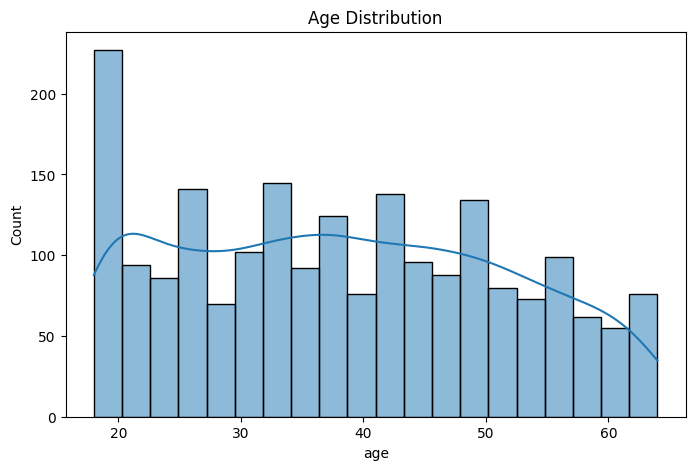

In [ ]:
plt.figure(figsize= (8,5))
sns.histplot(df2.age,bins= 20 ,kde= True)
plt.title('Age Distribution')
plt.show()

### BMI Distribution

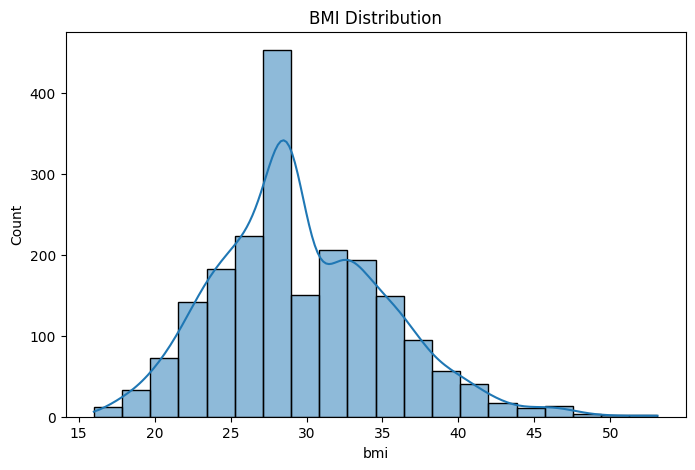

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df2['bmi'], bins=20, kde=True)
plt.title('BMI Distribution')
plt.show()

### Weight Distribution

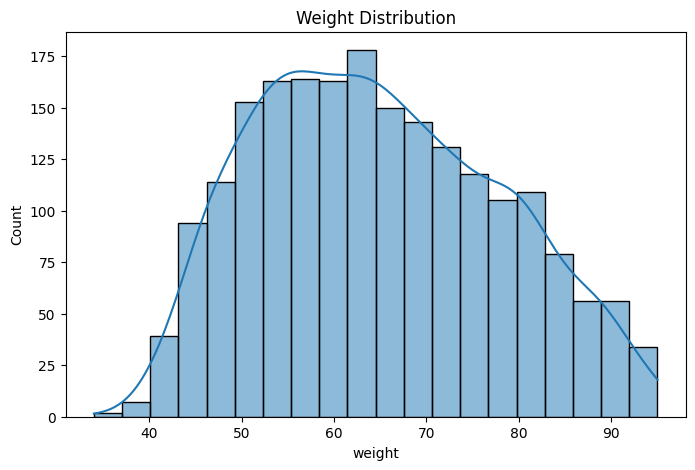

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df2['weight'], bins=20, kde=True)
plt.title('Weight Distribution')
plt.show()

### Blood Pressure Distribution

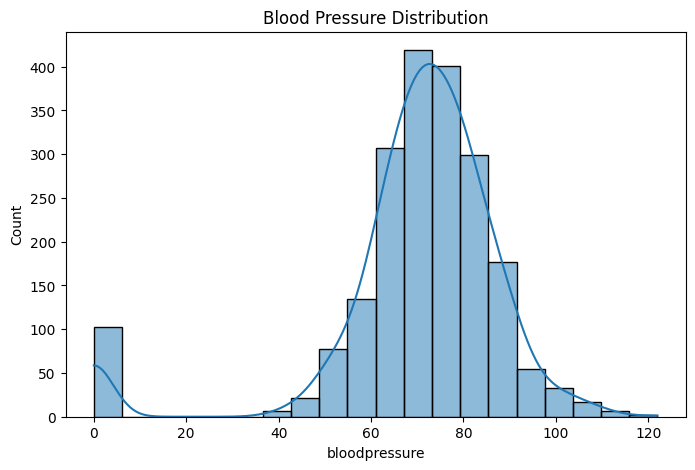

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df2['bloodpressure'], bins=20, kde=True)
plt.title('Blood Pressure Distribution')
plt.show()

### Claim Distribution

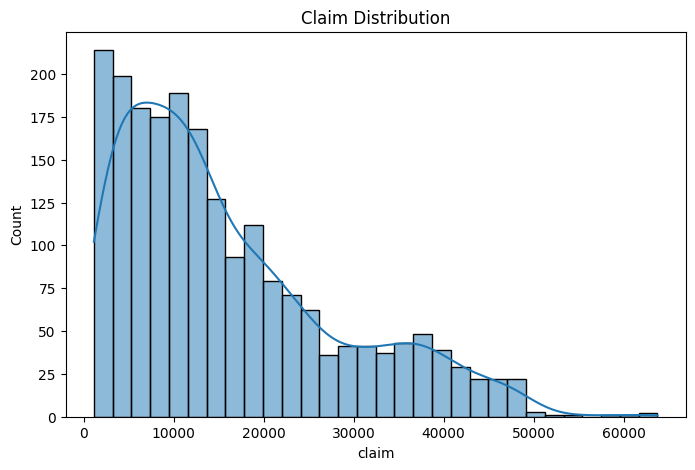

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df2['claim'], bins=30, kde=True)
plt.title('Claim Distribution')
plt.show()

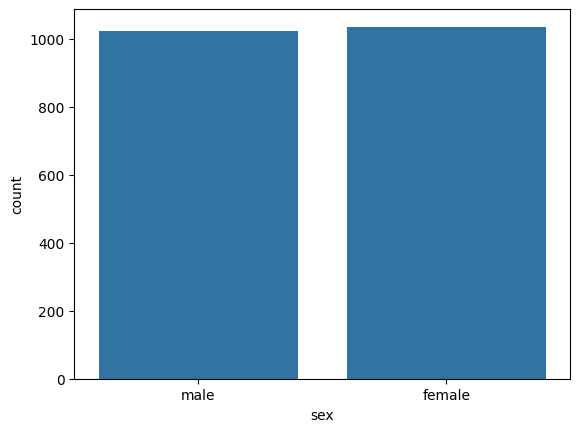

In [ ]:
sns.countplot(data=df2,x='sex')
plt.show()

In [ ]:
df2.columns

Index(['age', 'sex', 'weight', 'bmi', 'hereditary_diseases',
       'no_of_dependents', 'smoker', 'bloodpressure', 'diabetes', 'regular_ex',
       'job_title', 'claim'],
      dtype='object')

### Disease

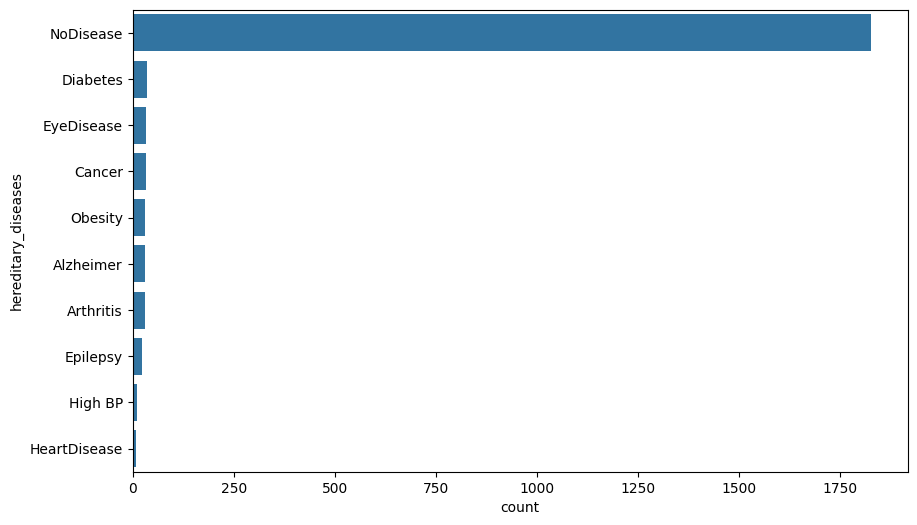

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df2,
              y='hereditary_diseases',
              order=df2['hereditary_diseases'].value_counts().index)
plt.show()


### Job Title

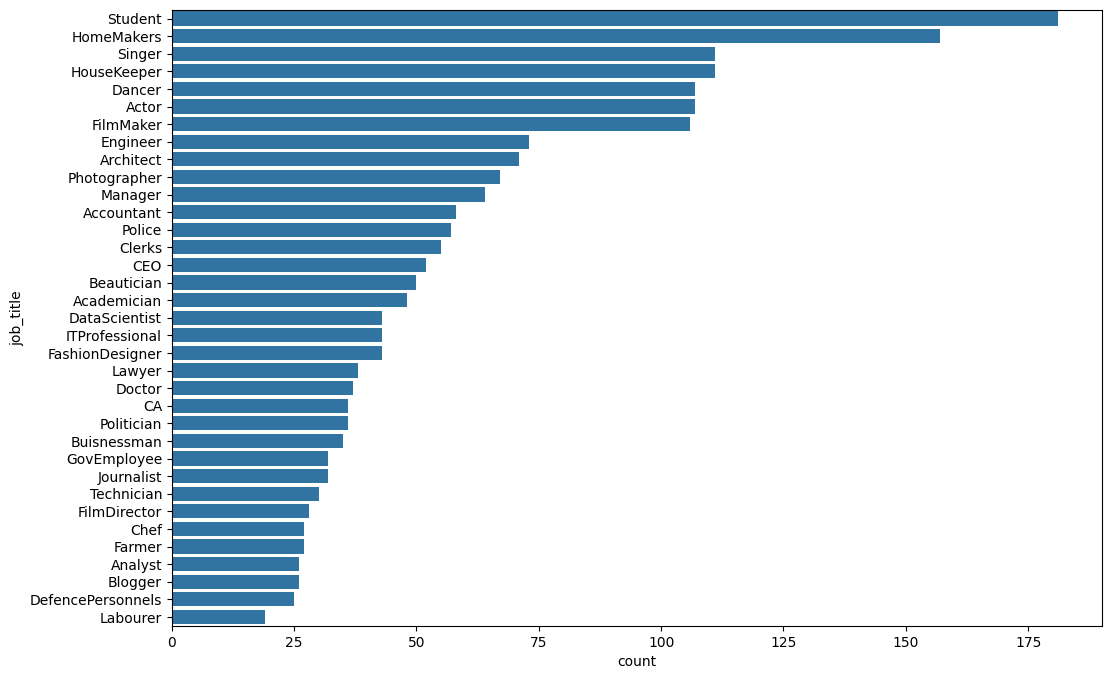

In [ ]:
plt.figure(figsize=(12,8))
sns.countplot(
    data=df2,
    y='job_title',
    order=df2['job_title'].value_counts().index
)
plt.show()

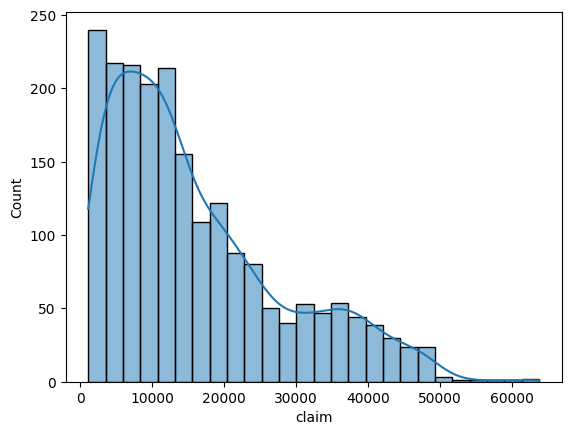

In [ ]:
sns.histplot(df2['claim'], kde=True)
plt.show()

In [ ]:
print(df2['claim'].skew())

1.0167646756069935


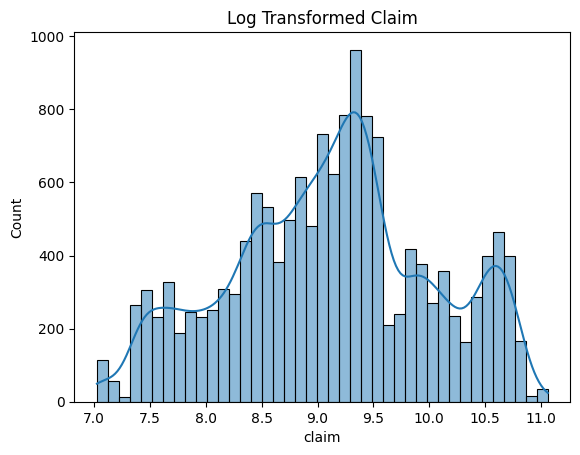

In [ ]:
sns.histplot(np.log1p(df['claim']), kde=True)
plt.title('Log Transformed Claim')
plt.show()

### Outlier Analysis

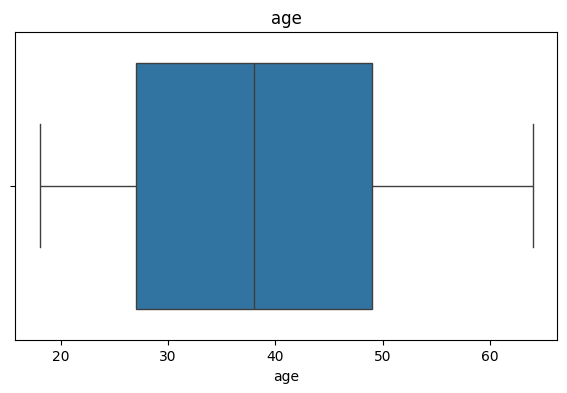

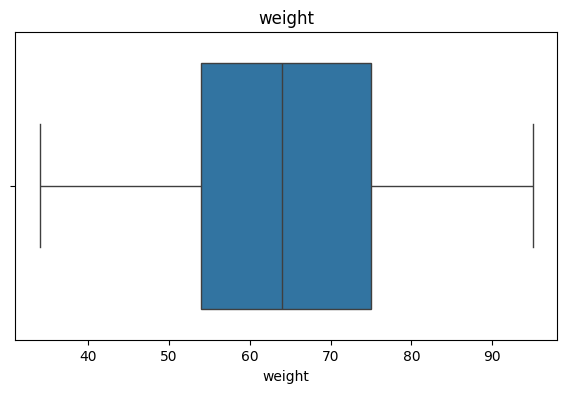

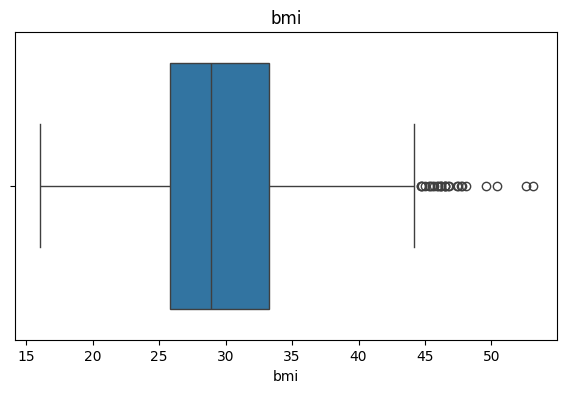

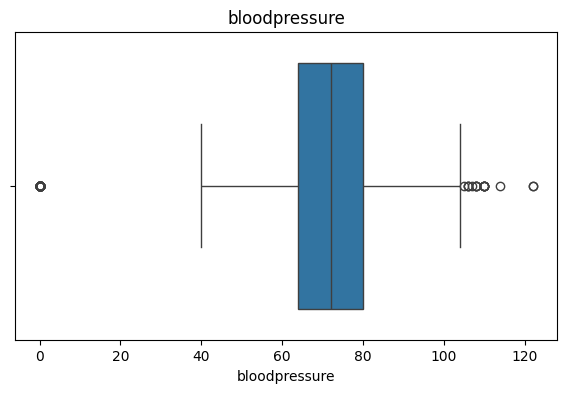

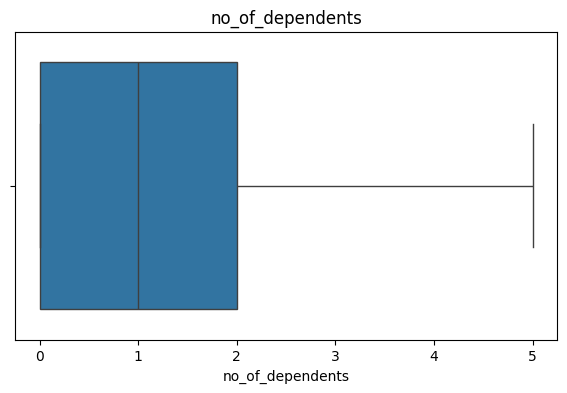

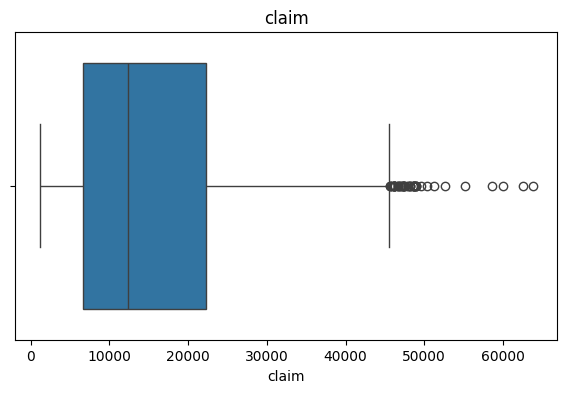

In [ ]:
num_cols = [
    'age',
    'weight',
    'bmi',
    'bloodpressure',
    'no_of_dependents',
    'claim'
]
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df2[col])
    plt.title(col)
    plt.show()



In [ ]:
num_cols = [
    'age',
    'weight',
    'bmi',
    'bloodpressure',
    'no_of_dependents',
    'claim'
]
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[
        (df[col]<lower) |
        (df[col]>upper)
    ]

    print(col,len(outliers))


age 0
weight 0
bmi 61
bloodpressure 893
no_of_dependents 0
claim 1642


### **Bivariate Analysis**

### Age vs Claim

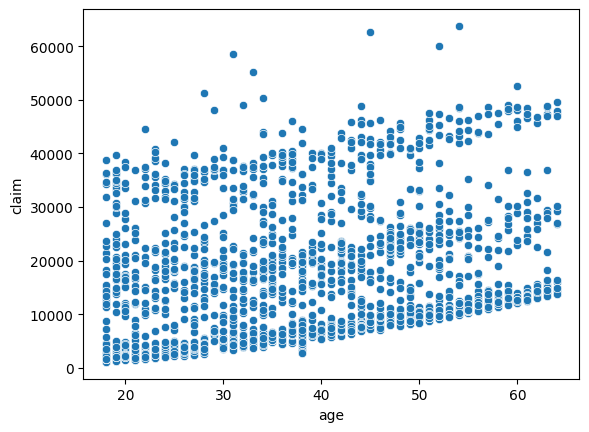

In [ ]:
# Age increases claim burden.
# Young healthy customers are profitable segments.
sns.scatterplot(
    data=df2,
    x='age',
    y='claim'
)
plt.show()

###  BMI vs Claim

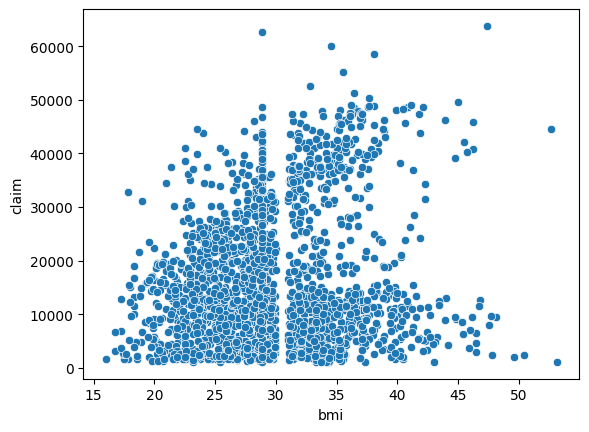

In [ ]:
sns.scatterplot(
    data=df2,
    x='bmi',
    y='claim'
)
plt.show()

### Weight vs Claim

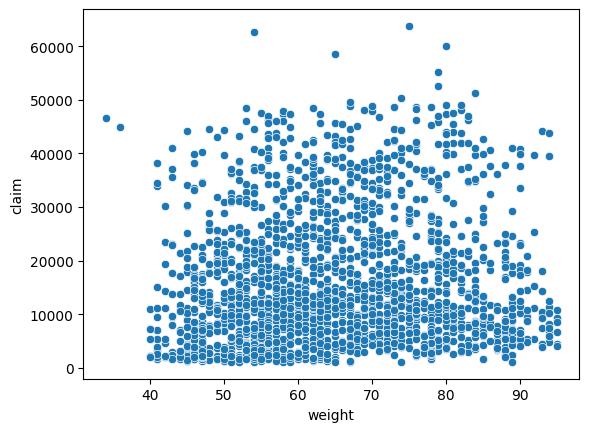

In [ ]:
sns.scatterplot(
    data=df2,
    x='weight',
    y='claim'
)
plt.show()

### Smoker vs Claim

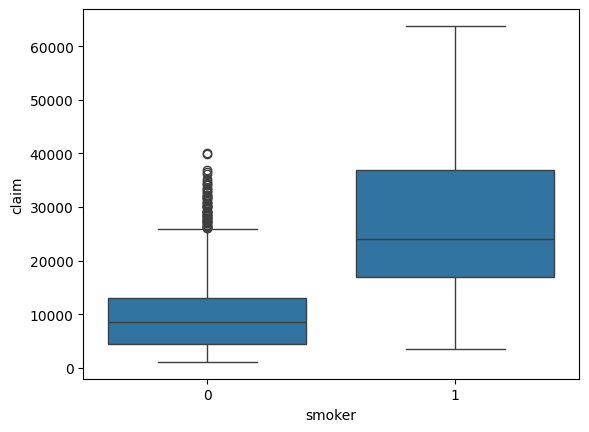

In [ ]:
# Smokers generate substantially higher claims.
sns.boxplot(
    data=df2,
    x='smoker',
    y='claim'
)
plt.show()

### Diabetes vs Claim

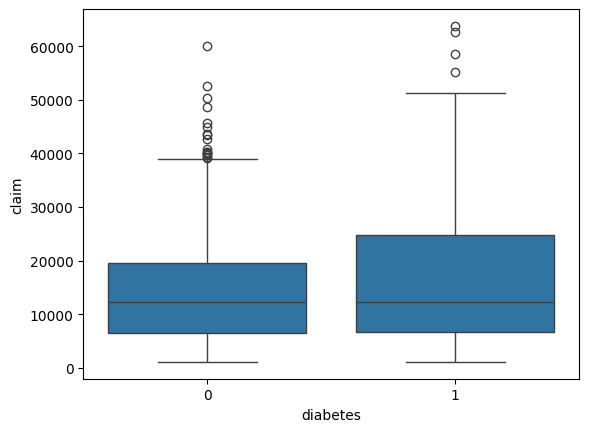

In [ ]:
# Diabetes contributes to higher claims.
sns.boxplot(
    data=df2,
    x='diabetes',
    y='claim'
)
plt.show()

### Disease vs Claim

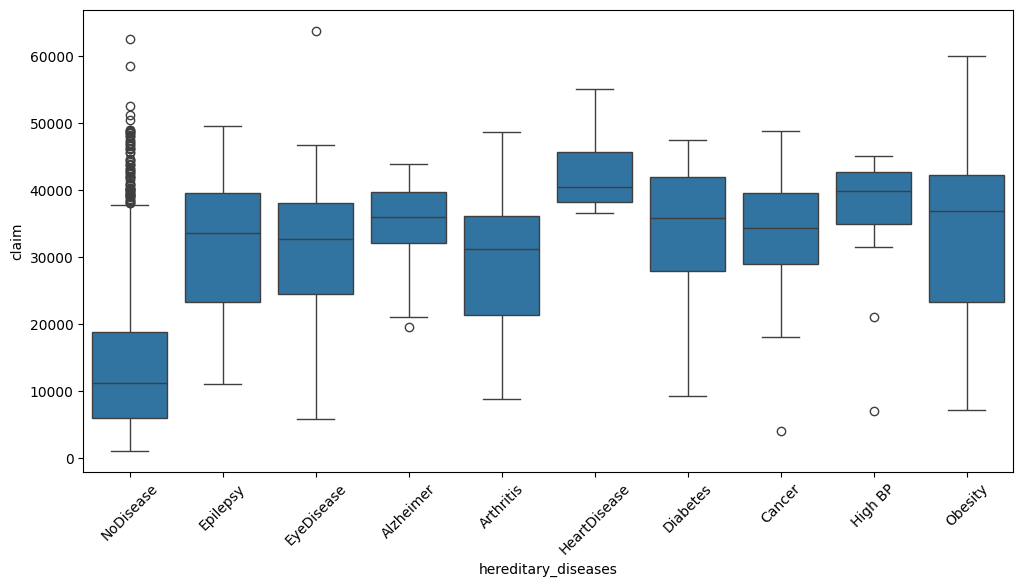

In [ ]:
# Disease history strongly impacts claim.
# Obese customers likely cost more.
# Diabetes contributes to higher claims.
# Lifestyle indicators improve claim prediction.

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df2,
    x='hereditary_diseases',
    y='claim'
)

plt.xticks(rotation=45)
plt.show()

### Dependents vs Claim

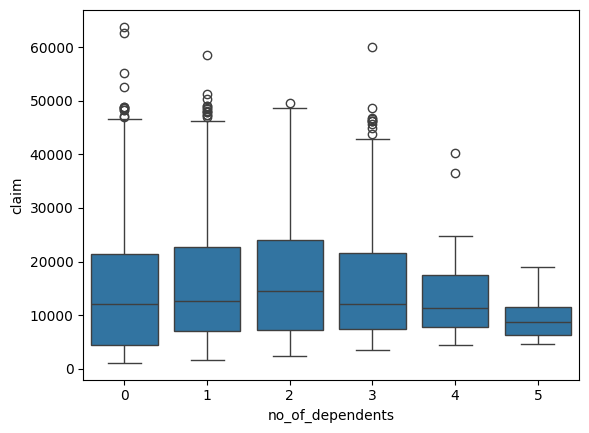

In [ ]:
sns.boxplot(
    data=df2,
    x='no_of_dependents',
    y='claim'
)
plt.show()

### Exercise vs Claim

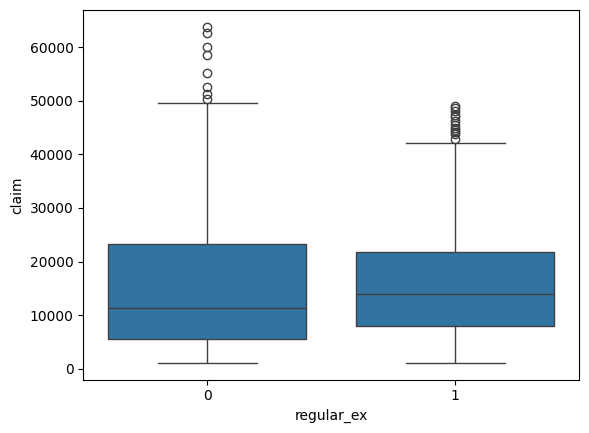

In [ ]:
sns.boxplot(
    data=df2,
    x='regular_ex',
    y='claim'
)
plt.show()

### Job Title vs Claim

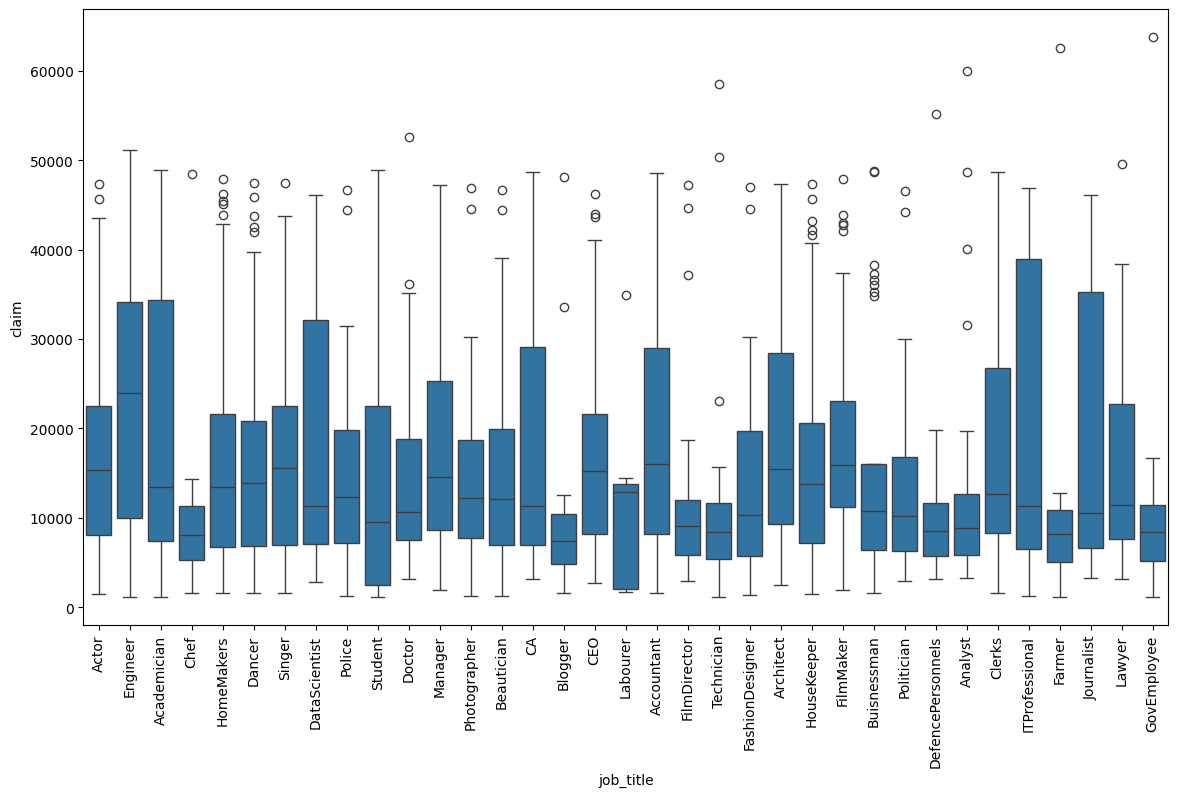

In [ ]:
plt.figure(figsize=(14,8))

sns.boxplot(
    data=df2,
    x='job_title',
    y='claim'
)

plt.xticks(rotation=90)
plt.show()

### Multivariate Analysis

### Correlation Heatmap

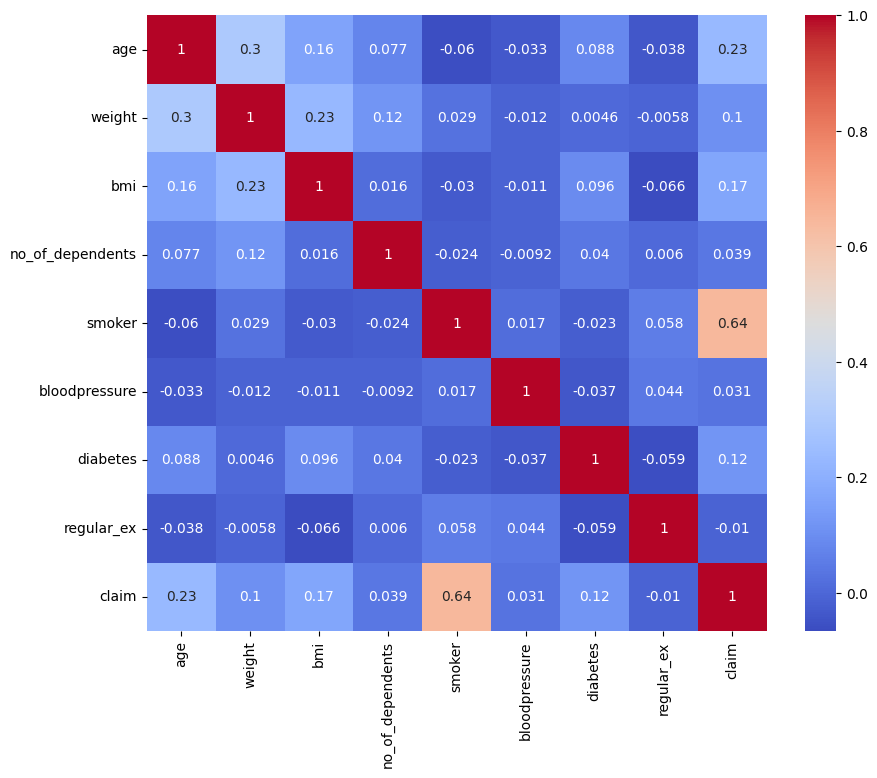

In [ ]:
plt.figure(figsize=(10,8))

corr = df2.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

### Pairplot

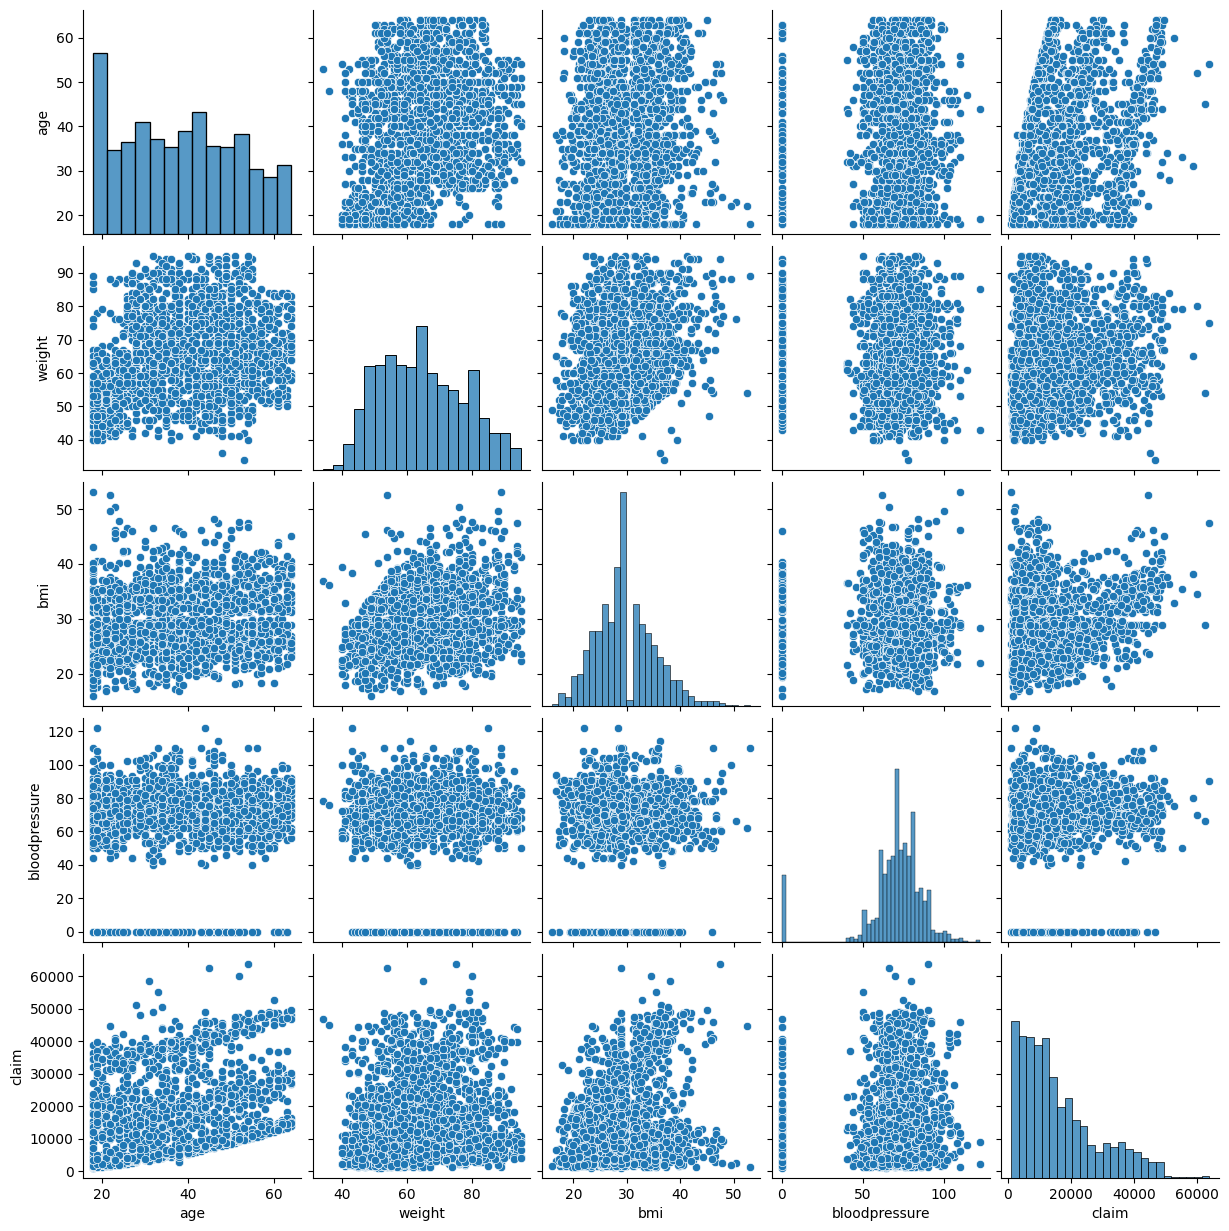

In [ ]:
sns.pairplot(
    df2[
        [
            'age',
            'weight',
            'bmi',
            'bloodpressure',
            'claim'
        ]
    ]
)

plt.show()

### BMI Risk Groups

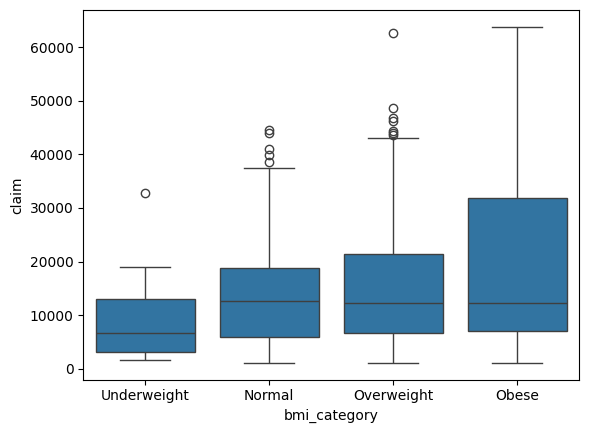

In [ ]:
df2['bmi_category'] = pd.cut(
    df2['bmi'],
    bins=[0,18.5,25,30,100],
    labels=[
        'Underweight',
        'Normal',
        'Overweight',
        'Obese'
    ]
)

sns.boxplot(
    data=df2,
    x='bmi_category',
    y='claim'
)
plt.show()